# Visión por Computadora II #

## CEIA 21Co2025 ##

## TP Integrador ##

José Luis Diaz (diazjoseluis@gmail.com)

Ricardo Silvera (rsilvera@thalu.com.ar)

José Aviani (jose.aviani@gmail.com)


---

### Dataset: ###

#### 'X-Ray Baggage Scanner Anomaly Detection' de Kaggle ####

https://www.kaggle.com/datasets/orvile/x-ray-baggage-anomaly-detection/ 

##### Tipo de dataset #####

El conjunto de datos “X-Ray Baggage Scanner Anomaly Detection” de Kaggle contiene imágenes de rayos X de equipaje obtenidas en escáneres de seguridad. Las imágenes muestran valijas y bolsos con objetos superpuestos y densidades distintas. Este es un problema de detección de objetos.

##### Estructura #####

Cada imagen (en formato jpg) está acompañada por un archivo (txt) en formato YOLO, donde se indican las regiones que contienen objetos de interés mediante bounding boxes y un identificador de clase. Estas clases corresponden a 5 objetos potencialmente peligrosos:

“Tijera” (0), “Navaja” (1), “Cuchillo” (2), “Cutter” (3) y “Navaja Multiuso” (4).

Una misma imagen puede no contener ninguna amenaza, o incluir varias instancias de distintos tipos. Las etiquetas están en formato YOLO: cada .txt contiene 0 o más líneas con

    class_id x_center y_center width height (normalizado 0–1)

correspondientes a los objetos (clases) en la imagen.

El dataset contiene tres folders: “train”, “valid” y “test”. A su vez cada uno de estos folders contierne dos folders: “images” (con las imágenes el formato jpg) y “labels” (los labes en formato txt/YOLO).

---

Importar librerias:

In [ ]:
%pip install gdown
%pip install torch
%pip install torchvision
%pip install matplotlib

In [2]:
import os
import zipfile
import gdown
import shutil
import glob
import torch
import torchvision
import numpy as np
from collections import Counter
from PIL import Image
import random
import matplotlib.pyplot as plt
from torchvision.ops import box_convert

In [3]:
random.seed(42)

---

#### Descargar dataset ####

In [4]:
data_dir = os.path.join(os.getcwd(), "data")

def descargar_dataset(data_dir):

  # Verificar si exsite la carpeta
  if not os.path.exists(data_dir):

    try:
      # Nombre del archivo ZIP que se va a guardar
      ZIP_NAME = "kaggle-xray_baggage_scanner_anomaly_detection.zip"
      zip_path = os.path.join(data_dir, ZIP_NAME)

      # Crear carpeta data
      os.makedirs(data_dir, exist_ok=True)

      # Descargar el ZIP
      print("Descargando archivo zip ...")
      # Lo tomamos de Google Drive porque Kaggle requeire autenticación
      gdown.download(id="1IqPblTm7nmKFpHXtl4beopE_SajTBoI0", output=zip_path, quiet=False)
      print("Archivo zip descargado.")

      # Descomprimir el ZIP
      print("Descomprimiendo archivo ...")
      with zipfile.ZipFile(zip_path, "r") as zf:
          zf.extractall(data_dir)
      print("Archivo descomprimido.")
    except:
      # En caso de error, eliminar la carpeta creada
      shutil.rmtree(data_dir, ignore_errors=True)
      print("Ocurrió un error al descargar el dataset.")

  print(f"Dataset descargado en: '{data_dir}'")


# Descargar el dataset (solo si no existe la carpeta data)
descargar_dataset(data_dir)

Dataset descargado en: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data'


---

#### Cargar dataset ####

In [29]:
data_dir = os.path.join(os.getcwd(), "data")
# Dataset YOLO

CLASS_NAMES = ['tijera', 'navaja', 'cuchillo', 'cutter', 'navaja multiuso']

class YoloDetectionDataset(torch.utils.data.Dataset):
    def __init__(self, dir_name, transforms=None):
        dir_path = os.path.join(data_dir, dir_name)
        images_dir = os.path.join(dir_path, "images")
        labels_dir = os.path.join(dir_path, "labels")
        
        self.images = sorted(glob.glob(os.path.join(images_dir, "*")))
        self.labels_dir = labels_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def _read_yolo_txt(self, label_path):
        boxes_cxcywh = []
        labels = []
        if not os.path.exists(label_path):
            return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
        with open(label_path, "r") as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]
        if not lines:
            return torch.zeros((0,4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)
        for ln in lines:
            c, cx, cy, w, h = ln.split()
            labels.append(int(c))
            boxes_cxcywh.append([float(cx), float(cy), float(w), float(h)])
        return torch.tensor(boxes_cxcywh, dtype=torch.float32), torch.tensor(labels, dtype=torch.int64)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        base = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(self.labels_dir, base + ".txt")
        boxes_cxcywh_norm, labels = self._read_yolo_txt(lbl_path)

        # Desnormalizar a píxeles
        if boxes_cxcywh_norm.numel() > 0:
            scale = torch.tensor([W, H, W, H], dtype=torch.float32)
            boxes_cxcywh_px = boxes_cxcywh_norm * scale
            boxes_xyxy = box_convert(boxes_cxcywh_px, in_fmt="cxcywh", out_fmt="xyxy")
            # Clampear por seguridad
            boxes_xyxy[:, [0,2]] = boxes_xyxy[:, [0,2]].clamp(0, W)
            boxes_xyxy[:, [1,3]] = boxes_xyxy[:, [1,3]].clamp(0, H)
        else:
            boxes_xyxy = torch.zeros((0,4), dtype=torch.float32)

        target = {
            "boxes": boxes_xyxy,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": ((boxes_xyxy[:,2]-boxes_xyxy[:,0]) * (boxes_xyxy[:,3]-boxes_xyxy[:,1]))
              if boxes_xyxy.numel() else torch.tensor([], dtype=torch.float32),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

def collate_fn(batch):
    imgs, targets = list(zip(*batch))
    return list(imgs), list(targets)


In [30]:
dataloader_batch_size = 32

transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

train_dataset = YoloDetectionDataset("train", transforms=transforms)
valid_dataset = YoloDetectionDataset("valid", transforms=transforms)
test_dataset = YoloDetectionDataset("test", transforms=transforms)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=dataloader_batch_size, shuffle=True, collate_fn=collate_fn)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=dataloader_batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=dataloader_batch_size, shuffle=True, collate_fn=collate_fn)

In [31]:
print (f"Imágenes de train: {len(train_dataloader.dataset)}")
print (f"Imágenes de valid: {len(valid_dataloader.dataset)}")
print (f"Imágenes de test: {len(test_dataloader.dataset)}")

Imágenes de train: 6181
Imágenes de valid: 1766
Imágenes de test: 883


---

#### Validar el dataset ####

Verificamos el dataset:

In [32]:
def chequeo_consistencia(dir_name):
    dir_path = os.path.join(data_dir, dir_name)
    images_dir = os.path.join(dir_path, "images")
    labels_dir = os.path.join(dir_path, "labels")

    # Listar imágenes y labels
    img_paths = sorted(glob.glob(os.path.join(images_dir, "*")))
    lbl_paths = sorted(glob.glob(os.path.join(labels_dir, "*.txt")))
    
    img_names = {os.path.splitext(os.path.basename(p))[0] for p in img_paths}
    lbl_names = {os.path.splitext(os.path.basename(p))[0] for p in lbl_paths}
    
    # Correspondencias
    imgs_sin_label = img_names - lbl_names     # imágenes sin .txt
    labels_sin_img = lbl_names - img_names     # .txt sin imagen
    
    # Contar .txt vacíos vs .txt con contenido
    num_txt_vacios = 0
    num_txt_con_lineas = 0
    
    for lp in lbl_paths:
        with open(lp, "r") as f:
            lineas = [ln.strip() for ln in f.readlines() if ln.strip()]
        if len(lineas) == 0:
            num_txt_vacios += 1
        else:
            num_txt_con_lineas += 1
    
    print(f"Dataset verificado: {dir_name}")
    print(f"     Directorio imágenes: '{images_dir}'")
    print(f"     Directorio labels:   '{labels_dir}'")
    print(f"     Total imágenes:      {len(img_paths)}")
    print(f"     Total .txt labels:   {len(lbl_paths)}")
    print(f"     .txt vacíos:         {num_txt_vacios}")
    print(f"     .txt con anotaciones:{num_txt_con_lineas}")
    print(f"     Imágenes sin .txt:   {len(imgs_sin_label)}")
    print(f"     .txt sin imagen:     {len(labels_sin_img)}")


chequeo_consistencia("train")
chequeo_consistencia("valid")
chequeo_consistencia("test")

Dataset verificado: train
     Directorio imágenes: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/train/images'
     Directorio labels:   '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/train/labels'
     Total imágenes:      6181
     Total .txt labels:   6181
     .txt vacíos:         0
     .txt con anotaciones:6181
     Imágenes sin .txt:   0
     .txt sin imagen:     0
Dataset verificado: valid
     Directorio imágenes: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/valid/images'
     Directorio labels:   '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/valid/labels'
     Total imágenes:      1766
     Total .txt labels:   1766
     .txt vacíos:         0
     .txt con anotaciones:1766
     Imágenes sin .txt:   0
     .txt sin imagen:     0
Dataset verificado: test
     Directorio imágenes: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-T

Con este resultado podemos verificar que:
* todas las imagenes (archivos jpg) tienen su label correspondiente (archivo txt - si una imagen no tiene ningún objecto detectado, el txt debe existir, pero vacío).
* todos los nombres de los archivos de inágenes corresponden a todos los nombres de los archivos de los labels.
* la cantidad de archivos en el dataset (para train, valid y test) coinciden a los datos cargados en los data loaders.

<br />

Verificamos las imágenes:

In [33]:
def analizar_propiedades_imagenes(dir_name, max_print=10):
    dir_path = os.path.join(data_dir, dir_name)
    images_dir = os.path.join(dir_path, "images")

    img_paths = sorted(glob.glob(os.path.join(images_dir, "*")))
    if not img_paths:
        print(f"[{images_dir}] No se encontraron imágenes.")
        return

    combos = Counter()   # (width, height, channels, dtype)
    modos = Counter()    # img.mode (PIL)
    dtypes = Counter()   # np.array(img).dtype

    for path in img_paths:
        with Image.open(path) as img:
            w, h = img.size           # ancho, alto
            mode = img.mode           # p.ej. "L", "RGB", "RGBA", etc.
            arr = np.array(img)

            if arr.ndim == 2:
                canales = 1
            else:
                canales = arr.shape[2]

            dtype = arr.dtype

            modos[mode] += 1
            dtypes[dtype] += 1
            combos[(w, h, canales, dtype)] += 1

    print(f"Dataset verificado: {dir_name}")
    print(f"     Directorio: '{images_dir}'")
    print(f"     Total de imágenes: {len(img_paths)}")

    print("     Modos de color (PIL):")
    for m, c in modos.items():
        print(f"          {m}: {c}")

    print("     Tipos de dato (numpy dtypes):")
    for dt, c in dtypes.items():
        print(f"          {dt}: {c}")

    print("     Combinaciones (width, height, canales, dtype):")
    for (w, h, c, dt), count in combos.most_common(max_print):
        print(f"          {w}x{h}, canales={c}, dtype={dt}: {count} imágenes")

    if len(combos) == 1:
        print("     ✅ Todas las imágenes tienen el mismo tamaño, canales y dtype.")
    else:
        print("     ⚠️ Hay variabilidad en tamaño/canales/dtype entre las imágenes.")


analizar_propiedades_imagenes("train")
analizar_propiedades_imagenes("valid")
analizar_propiedades_imagenes("test")

Dataset verificado: train
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/train/images'
     Total de imágenes: 6181
     Modos de color (PIL):
          RGB: 6181
     Tipos de dato (numpy dtypes):
          uint8: 6181
     Combinaciones (width, height, canales, dtype):
          416x416, canales=3, dtype=uint8: 6181 imágenes
     ✅ Todas las imágenes tienen el mismo tamaño, canales y dtype.
Dataset verificado: valid
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/valid/images'
     Total de imágenes: 1766
     Modos de color (PIL):
          RGB: 1766
     Tipos de dato (numpy dtypes):
          uint8: 1766
     Combinaciones (width, height, canales, dtype):
          416x416, canales=3, dtype=uint8: 1766 imágenes
     ✅ Todas las imágenes tienen el mismo tamaño, canales y dtype.
Dataset verificado: valid
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2

Con este resultado podemos verificar que todas las imágenes tienen el mismo tamaño, canales y tipo.

Ahora generamos los histogramas de itensidad (RGB) de algunas imágenes:

Dataset: train
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/train/images'
     Muestra de 3 imágenes:

          Imagen: 027811_jpg.rf.4e7bf13bfd17b9b578c7eacf2be00e23.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 229.81


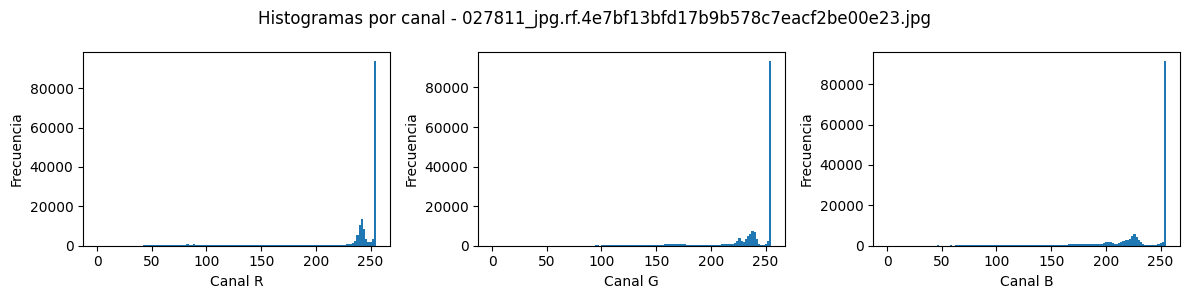

          Imagen: 038877_jpg.rf.5d609457de3ca9870874b9fb5d97d183.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 218.34


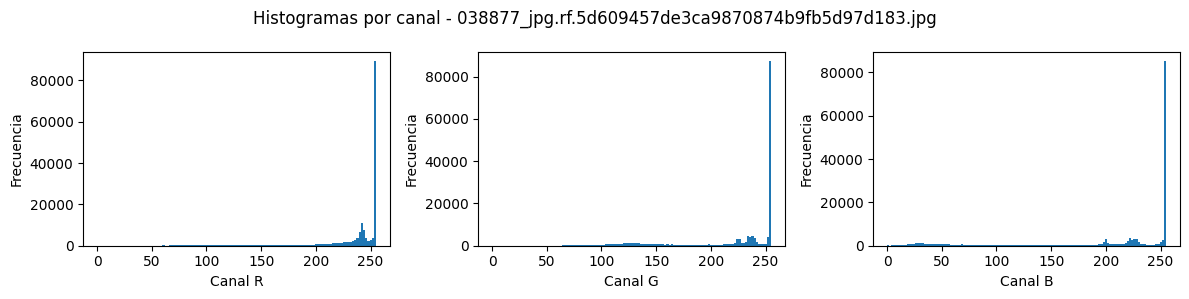

          Imagen: 038619_jpg.rf.e853b6a135e9e3a47d7da3259d8ce6cb.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 233.87


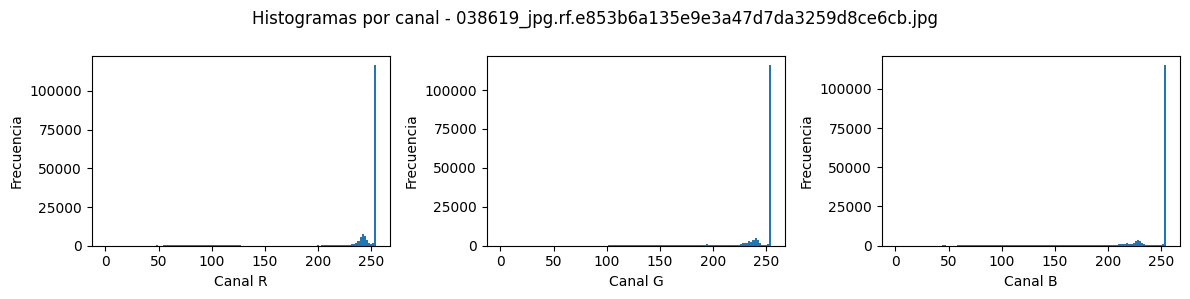

Dataset: valid
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/valid/images'
     Muestra de 3 imágenes:

          Imagen: 042950_jpg.rf.0cfa30f0f1ef4896e6a1bf5a6738ef45.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 232.58


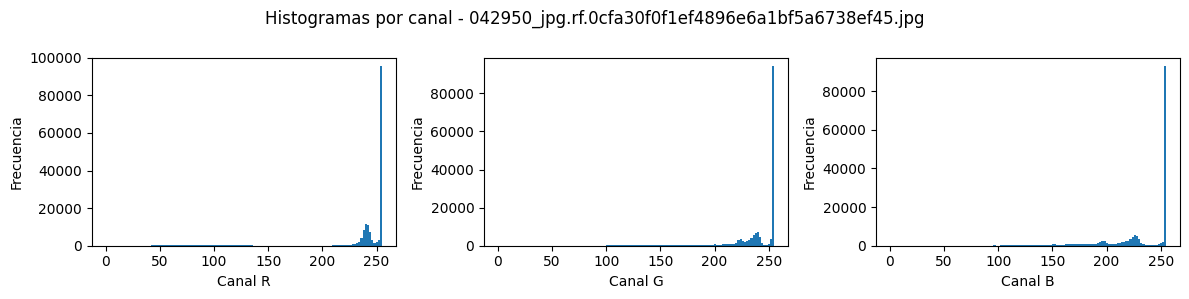

          Imagen: 028029_jpg.rf.c8799e1c2f11a1524e486dc51bc0b460.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 219.75


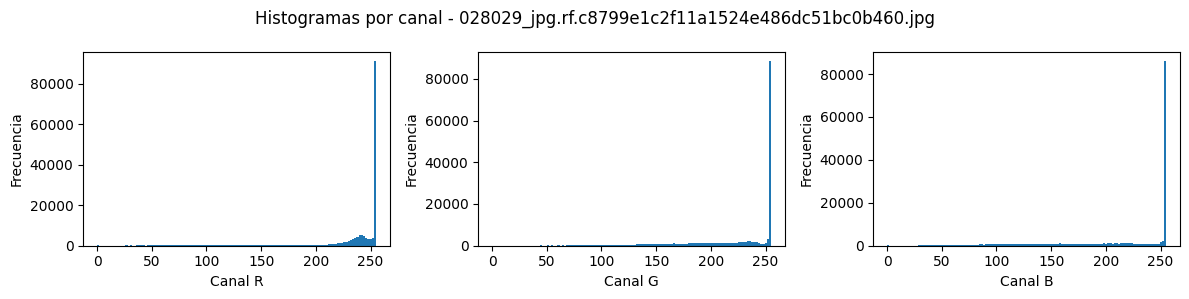

          Imagen: 035043_jpg.rf.63666e7896f4b67d87768247f416d0d5.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 244.17


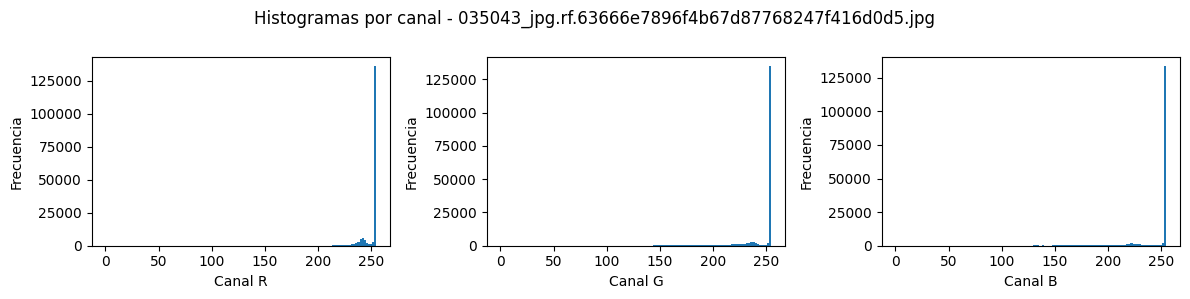

Dataset: test
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/test/images'
     Muestra de 3 imágenes:

          Imagen: 020250_jpg.rf.5b6fde2c1583699b076bb3ad40ba954b.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 240.42


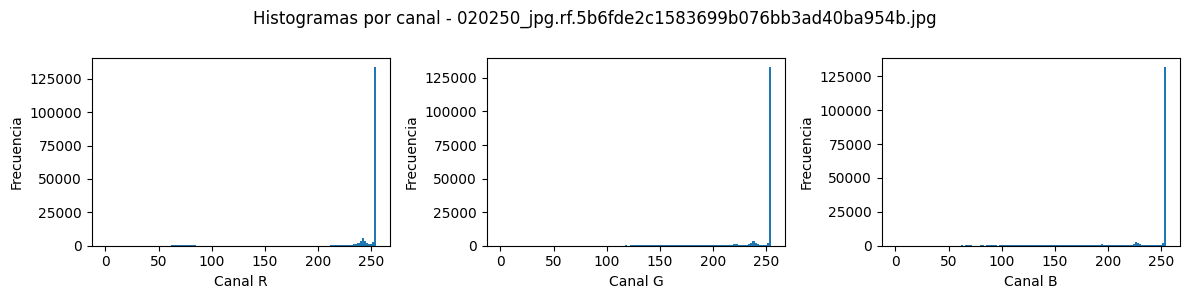

          Imagen: 038352_jpg.rf.02228eabac26cfb81cdaef6aa61f193a.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 240.83


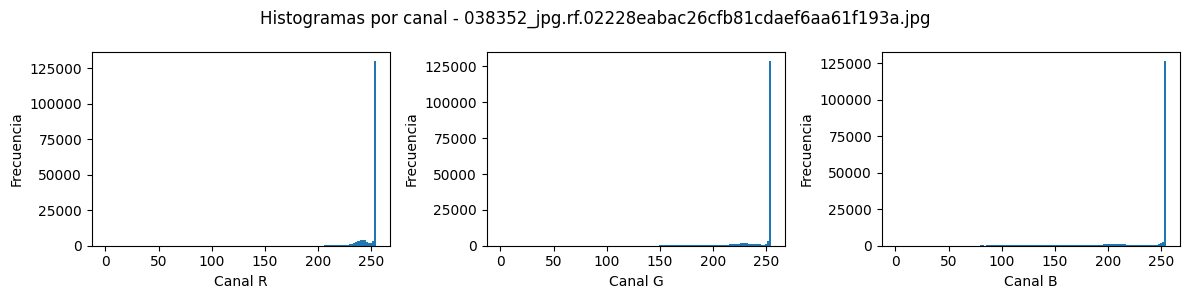

          Imagen: 010154_jpg.rf.66942a845d6c788b798e4f1cdd08c3b3.jpg
               Hape: (416, 416, 3), dtype: uint8
               Min: 0, max: 255, mean: 239.66


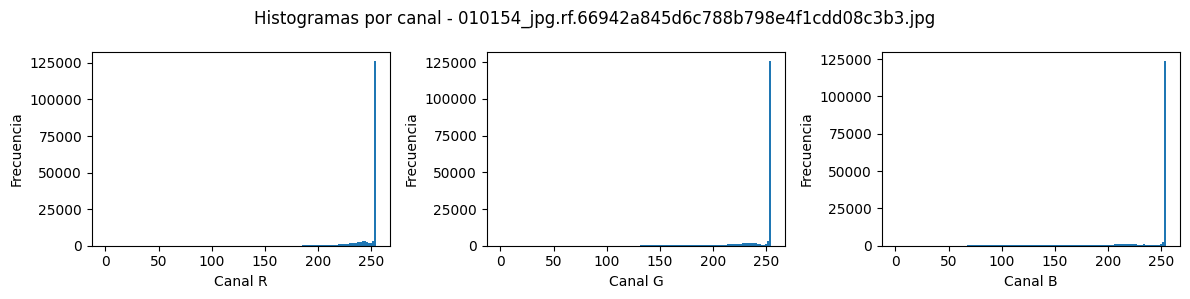

In [34]:
def mostrar_histogramas_intensidad(dir_name, num_samples):
    dir_path = os.path.join(data_dir, dir_name)
    images_dir = os.path.join(dir_path, "images")

    img_paths = sorted(glob.glob(os.path.join(images_dir, "*")))
    if not img_paths:
        print(f"[{images_dir}] No se encontraron imágenes.")
        return

    sample_paths = random.sample(img_paths, min(num_samples, len(img_paths)))

    print(f"Dataset: {dir_name}")
    print(f"     Directorio: '{images_dir}'")
    print(f"     Muestra de {len(sample_paths)} imágenes:\n")

    for path in sample_paths:
        with Image.open(path) as img:
            img = img.convert("RGB")
            arr = np.array(img)

        print(f"          Imagen: {os.path.basename(path)}")
        print(f"               Hape: {arr.shape}, dtype: {arr.dtype}")
        print(f"               Min: {arr.min()}, max: {arr.max()}, mean: {arr.mean():.2f}")

        # Histogramas por canal (R, G, B)
        canales = ["R", "G", "B"]
        plt.figure(figsize=(12, 3))
        plt.suptitle(f"Histogramas por canal - {os.path.basename(path)}")

        for c in range(3):
            plt.subplot(1, 3, c + 1)
            plt.hist(arr[..., c].flatten(), bins=128, range=(0, 255))
            plt.xlabel(f"Canal {canales[c]}")
            plt.ylabel("Frecuencia")

        plt.tight_layout()
        plt.show()


histograma_num_samples = 3

mostrar_histogramas_intensidad("train", num_samples=histograma_num_samples)
mostrar_histogramas_intensidad("valid", num_samples=histograma_num_samples)
mostrar_histogramas_intensidad("test",  num_samples=histograma_num_samples)

Acá sólo mostramos algunas pocas por grupo, pero revisamos varias más. Podemos observar que:

* La media es alta, en promedio los píxeles son bastantes claros (cercanos a la zona del blanco). Esto es común en imágenes de rayos X: gran parte es fondo claro y los objetos relevantes aparecen como estructuras más oscuras o de distinto tono.

* Los histogramas de R, G y B son muy parecidos. Esto indica que la imagen es pseudo-gris en RGB (mismo contenido replicado en los 3 canales o muy parecido). Para el modelo, esto es prácticamente una imagen en escala de grises.

* Esto no debería ser un problema: el modelo sigue teniendo información para distinguir objetos.

Ahora hacemos un análisis cuantitativo en todo el dataset del porcentaje de píxeles en 0 y 255:

In [35]:
def porcentaje_pixeles_0_255(dir_name):
    dir_path = os.path.join(data_dir, dir_name)
    images_dir = os.path.join(dir_path, "images")
    img_paths = sorted(glob.glob(os.path.join(images_dir, "*")))
    if not img_paths:
        print(f"[{images_dir}] No se encontraron imágenes.")
        return

    total_pixels = 0
    total_zeros = 0
    total_255 = 0

    for path in img_paths:
        with Image.open(path) as img:
            img = img.convert("RGB")  # aseguramos 3 canales
            arr = np.array(img)

        # aplanamos todos los canales
        flat = arr.flatten()
        total_pixels += flat.size
        total_zeros += np.count_nonzero(flat == 0)
        total_255 += np.count_nonzero(flat == 255)

    pct_zeros = 100.0 * total_zeros / total_pixels
    pct_255 = 100.0 * total_255 / total_pixels

    print(f"Dataset: {dir_name}")
    print(f"     Directorio: '{images_dir}'")
    print(f"     Total de imágenes: {len(img_paths)}")
    print(f"     Total de píxeles: {total_pixels}")
    print(f"     Píxeles == 0  : {total_zeros} ({pct_zeros:.3f} %)")
    print(f"     Píxeles == 255: {total_255} ({pct_255:.3f} %)")


porcentaje_pixeles_0_255("train")
porcentaje_pixeles_0_255("valid")
porcentaje_pixeles_0_255("test")

Dataset: train
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/train/images'
     Total de imágenes: 6181
     Total de píxeles: 3208977408
     Píxeles == 0  : 1450217 (0.045 %)
     Píxeles == 255: 72320385 (2.254 %)
Dataset: valid
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/valid/images'
     Total de imágenes: 1766
     Total de píxeles: 916850688
     Píxeles == 0  : 426847 (0.047 %)
     Píxeles == 255: 20499193 (2.236 %)
Dataset: valid
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/valid/images'
     Total de imágenes: 1766
     Total de píxeles: 916850688
     Píxeles == 0  : 426847 (0.047 %)
     Píxeles == 255: 20499193 (2.236 %)
Dataset: test
     Directorio: '/home/gury/Documentos/EIA/B4/Visión por computadora II/Tps/CEIA-VpC2-TP/data/test/images'
     Total de imágenes: 883
     Total de píxeles: 458425344
     Píxeles == 0  : 21

En todo el dataset sólo alrededor del 0.046% de los píxeles son negro puro, mientras que aproxímadamente el 2.25% de los píxeles son blancoi puro, verificando lo que vimos en los hinstagramas.

Estos resultados indican que el dataset presenta un rango dinámico razonable, sin predominio excesivo de áreas completamente saturadas, aunque con un claro sesgo hacia intensidades altas debido al fondo del escáner.

---

#### Análisis de imágenes negativas (sin objetos) ####

In [36]:
def contar_imagenes_sin_objetos(dl):
    total_imgs = 0
    sin_objetos = 0

    for imgs, targets in dl:              # targets = lista de dicts
        for t in targets:
            total_imgs += 1
            if t["boxes"].shape[0] == 0:  # 0 cajas -> imagen "negativa"
                sin_objetos += 1

    print("     Total de imágenes:", total_imgs)
    print("     Imágenes sin objetos:", sin_objetos)

print(f"Dataset: train")
contar_imagenes_sin_objetos(train_dataloader)
print(f"Dataset: valid")
contar_imagenes_sin_objetos(valid_dataloader)
print(f"Dataset: test")
contar_imagenes_sin_objetos(test_dataloader)

Dataset: train
     Total de imágenes: 6181
     Imágenes sin objetos: 0
Dataset: valid
     Total de imágenes: 6181
     Imágenes sin objetos: 0
Dataset: valid
     Total de imágenes: 1766
     Imágenes sin objetos: 0
Dataset: test
     Total de imágenes: 1766
     Imágenes sin objetos: 0
Dataset: test
     Total de imágenes: 883
     Imágenes sin objetos: 0
     Total de imágenes: 883
     Imágenes sin objetos: 0


Como podemos ver no hay ninguna imagen sin objetos etiquetados: todas contienen al menos una caja asociada a alguna clase. El dataset está compuesto exclusivamente por ejemplos positivos, esto no permite evaluar ni entrenar el modelo ante equipaje sin amenazas, algo a tener en cuenta por su impacto en los falsos positivos.

---

### Número de objetos por imágen

Recoremos todos los archvios txt y contamos la cantodad de objetos en cada uno

In [ ]:
def contar_objetos_por_imagen(dl):
    # Recorremos el dataloader y guardamos la cantidad de objetos por imagen
    conteos = []
    for _, targets in dl:
        for target in targets:
            conteos.append(target["labels"].shape[0])

    if not conteos:
        print("El dataloader no contiene imágenes.")
        return

    total_imagenes = len(conteos)
    total_objetos = sum(conteos)
    promedio_objetos = total_objetos / total_imagenes

    print(f"Total de imágenes analizadas: {total_imagenes}")
    print(f"Total de objetos detectados: {total_objetos}")
    print(f"Promedio de objetos por imagen: {promedio_objetos:.2f}")

    distribucion = Counter(conteos)
    print("\\nDistribución de objetos por imagen (n_objetos -> cantidad de imágenes):")
    for n_objetos, cantidad in sorted(distribucion.items()):
        print(f"  {n_objetos}: {cantidad}")

contar_objetos_por_imagen(train_dataloader)

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


#### Visualización de imágenes con bounding boxes ####

Seleccionamos 10  imágenes e al azar de cada clas del dataset de entrenamiento y mostramos las imágenes con sus bounding boxes correspondientes. Relizamos una inspección para verificar que se cumple correctamente el etiquetado de las imágenes, es decir que en el bounding box apareza un objeto del tipo etiquetado

Visualizando 10 imágenes por cada clase del dataset de entrenamiento...
Buscando imágenes por clase...


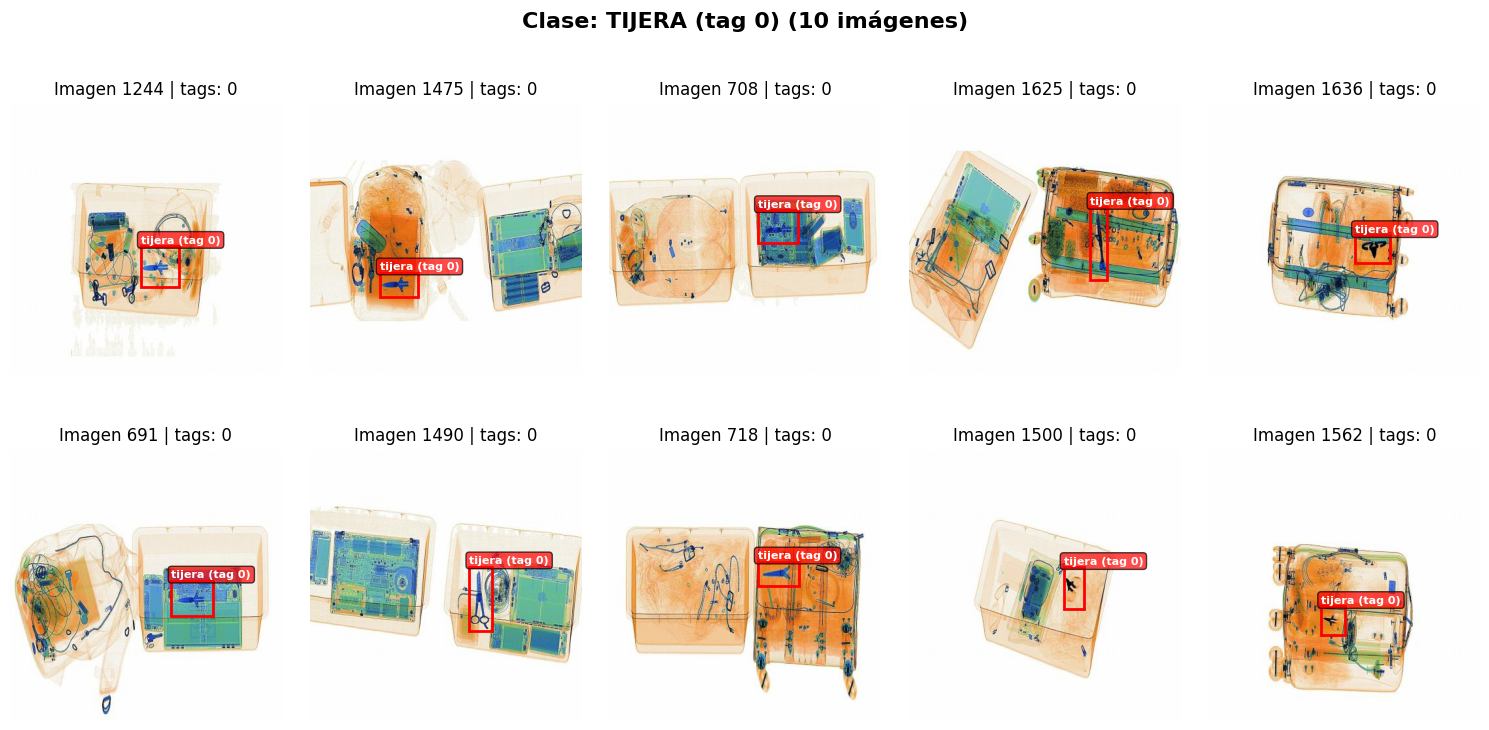

--------------------------------------------------


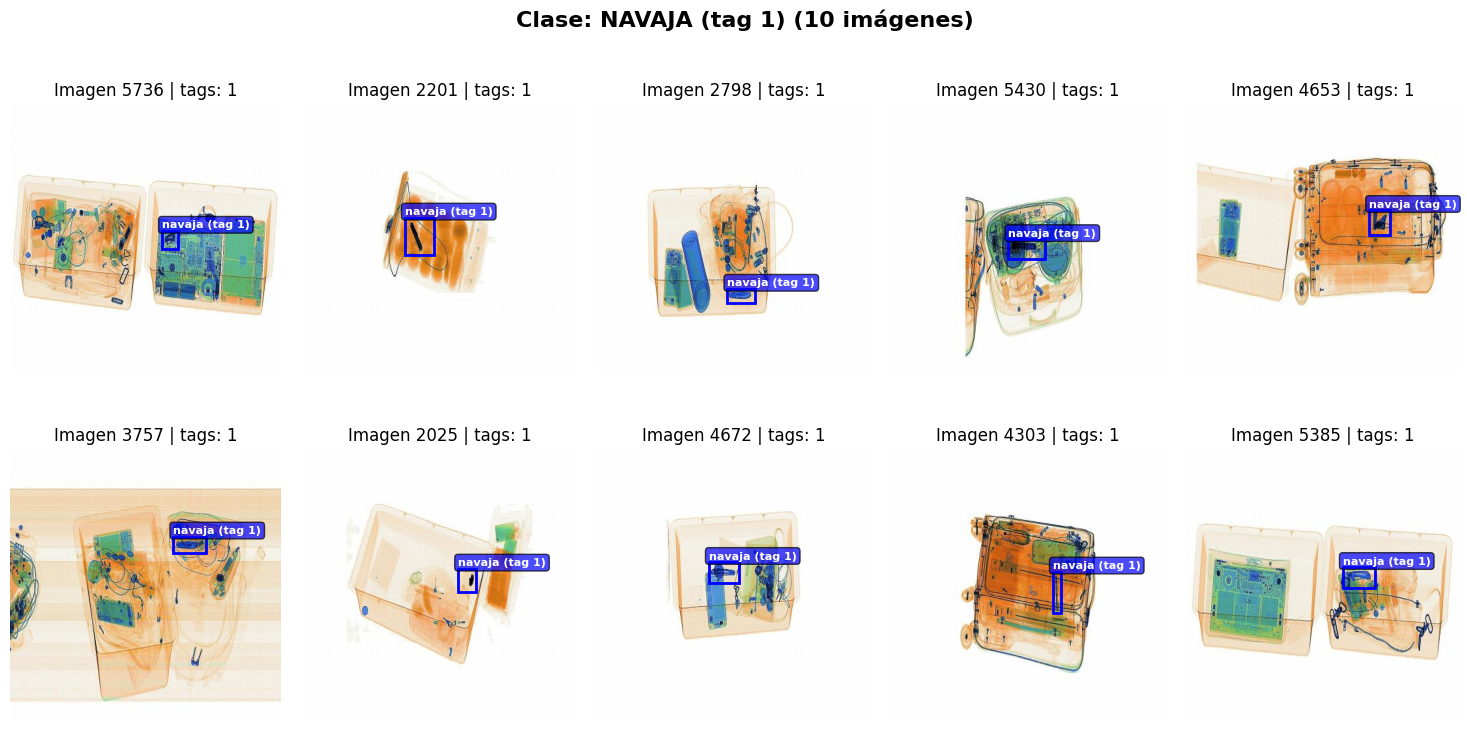

--------------------------------------------------


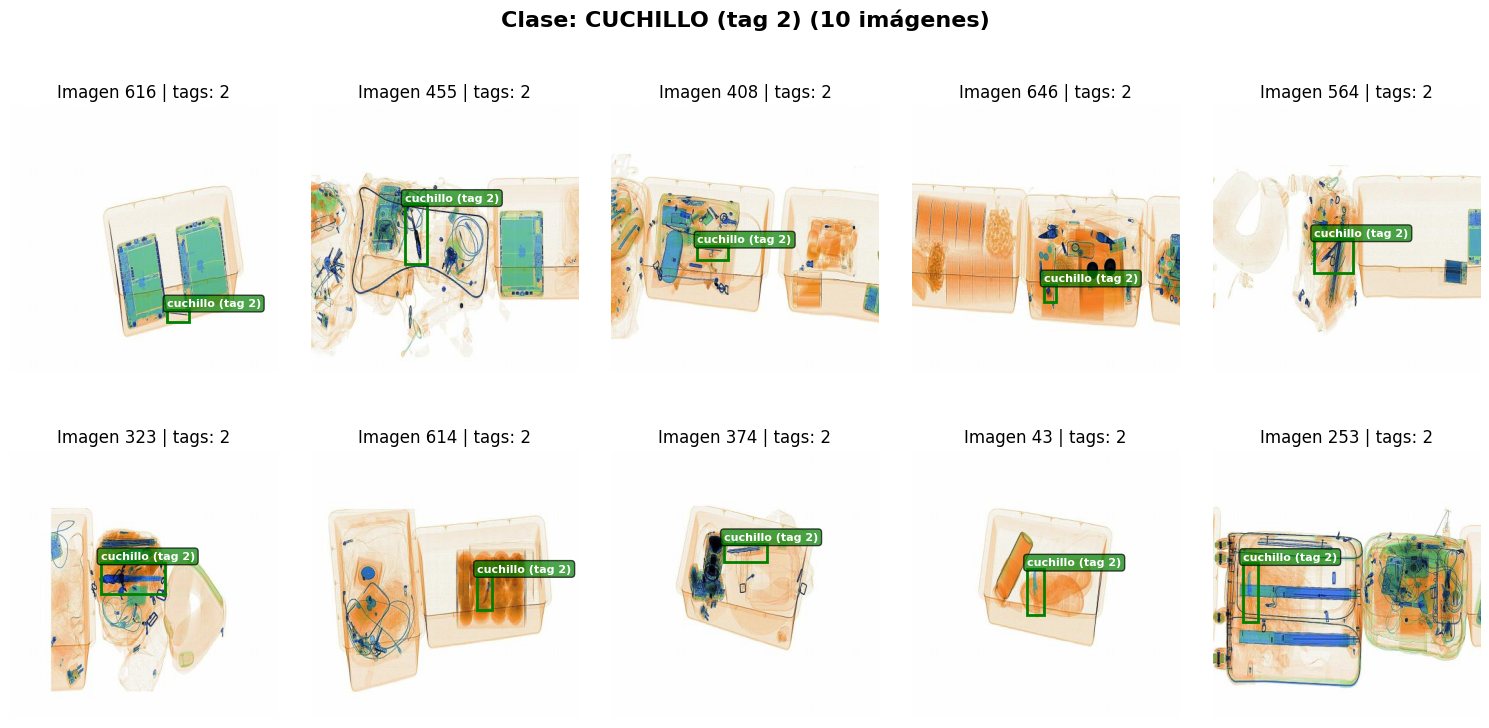

--------------------------------------------------


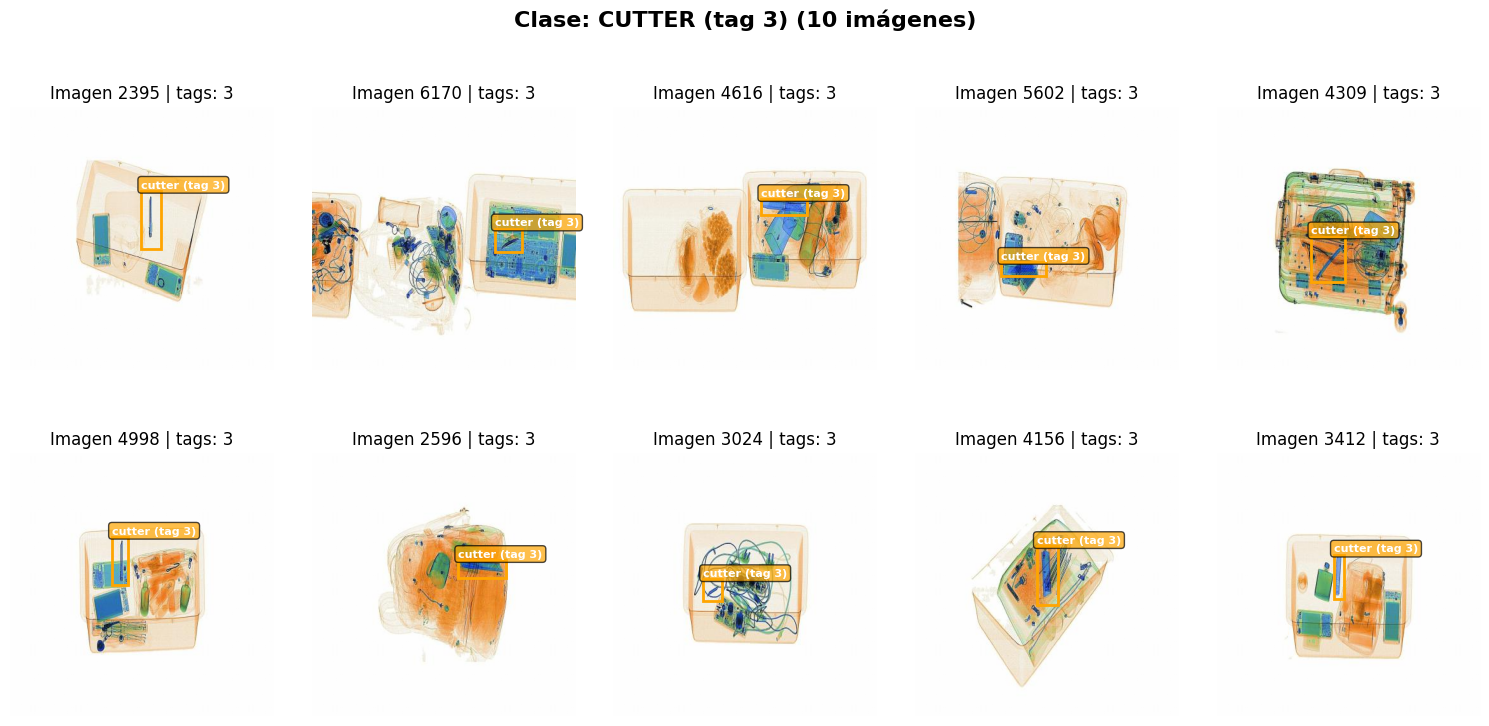

--------------------------------------------------


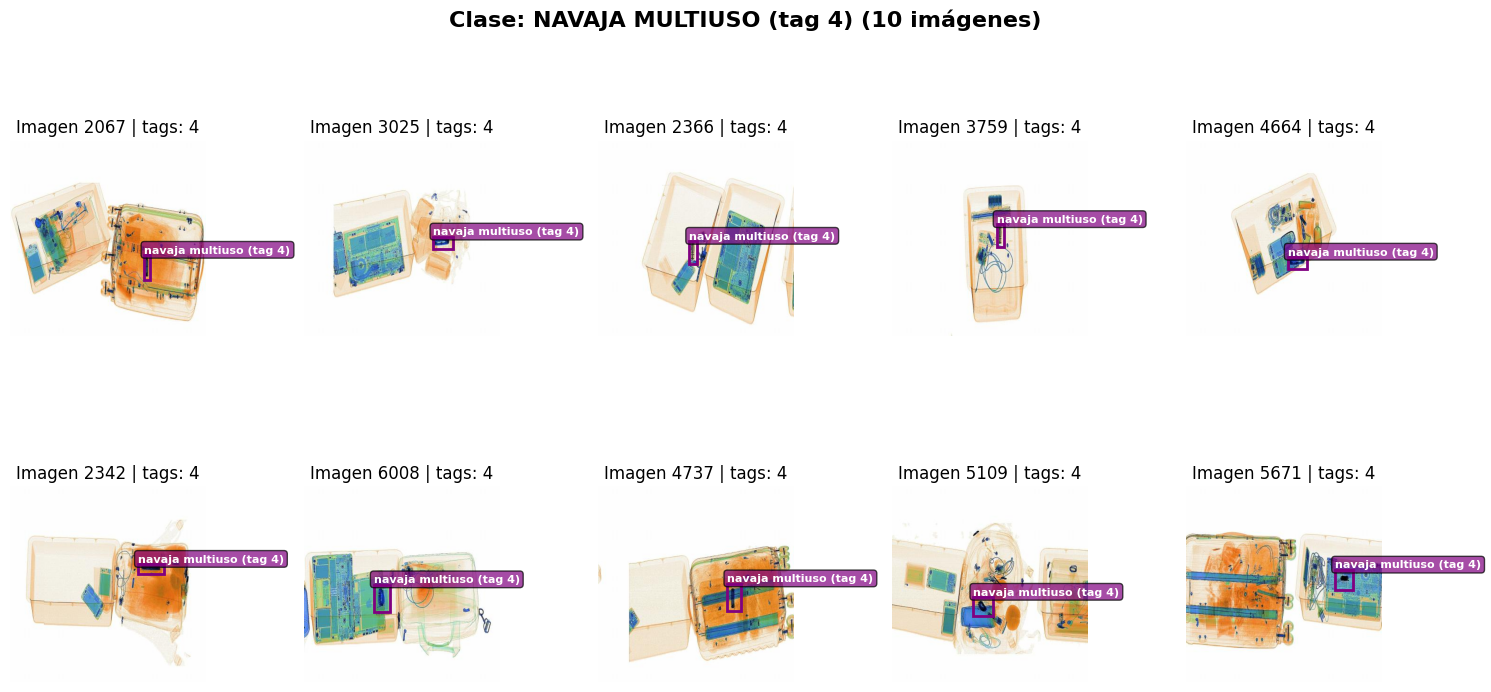

--------------------------------------------------


In [41]:
from collections import Counter


def visualizar_imagenes_por_clase(dataset, imagenes_por_clase=10, cols=2):
    """
    Visualiza imágenes del dataset organizadas por clase, mostrando una cantidad específica
    de imágenes que contengan cada tipo de objeto.

    Args:
        dataset: El dataset de imágenes
        imagenes_por_clase: Número de imágenes a mostrar por cada clase
        cols: Número de columnas en la grilla para cada clase
    """

    # Diccionario para almacenar índices únicos de imágenes por clase
    imagenes_por_tipo = {clase: set() for clase in range(len(CLASS_NAMES))}

    # Buscar imágenes que contengan cada clase
    print("Buscando imágenes por clase...")
    for idx in range(len(dataset)):
        _, target = dataset[idx]
        labels = target['labels']

        # Agregar este índice a todas las clases que aparecen en la imagen
        for label in labels:
            clase = label.item()
            imagenes_por_tipo[clase].add(idx)

   

    # Colores para cada clase
    colores_clases = {
        0: 'red',      # Tijeras
        1: 'blue',     # Navaja
        2: 'green',    # Cuchillo
        3: 'orange',   # Trincheta
        4: 'purple'    # Navaja multiuso
    }

    rng = random.Random()

    # Visualizar por cada clase
    for clase in range(len(CLASS_NAMES)):
        indices = list(imagenes_por_tipo[clase])
        if not indices:
            print(f"\n No se encontraron imágenes para la clase: {CLASS_NAMES[clase]}")
            continue

        # Seleccionar un subconjunto aleatorio para mostrar
        if len(indices) > imagenes_por_clase:
            indices_a_mostrar = rng.sample(indices, imagenes_por_clase)
        else:
            indices_a_mostrar = indices

        # Calcular filas necesarias
        rows = (len(indices_a_mostrar) + cols - 1) // cols

        # Crear figura para esta clase
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
        fig.suptitle(f'Clase: {CLASS_NAMES[clase].upper()} (tag {clase}) ({len(indices_a_mostrar)} imágenes)',
                     fontsize=16, fontweight='bold')

        # Asegurar que axes sea siempre un array 2D
        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = axes.reshape(1, -1)
        elif cols == 1:
            axes = axes.reshape(-1, 1)

        for i, idx in enumerate(indices_a_mostrar):
            row = i // cols
            col = i % cols
            ax = axes[row, col]

            # Obtener imagen y target
            img, target = dataset[idx]

            # Convertir tensor a array numpy y ajustar dimensiones
            if isinstance(img, torch.Tensor):
                img_np = img.permute(1, 2, 0).numpy()
            else:
                img_np = np.array(img)

            # Mostrar imagen
            etiquetas_presentes = sorted({label.item() for label in target['labels']})
            etiquetas_texto = ", ".join(str(tag) for tag in etiquetas_presentes) if etiquetas_presentes else "-"
            ax.imshow(img_np)
            ax.set_title(f'Imagen {idx} | tags: {etiquetas_texto}')
            ax.axis('off')

            # Dibujar bounding boxes
            boxes = target['boxes']
            labels = target['labels']

            for box, label in zip(boxes, labels):
                x1, y1, x2, y2 = box.numpy()
                width = x2 - x1
                height = y2 - y1

                # Crear rectángulo
                color = colores_clases.get(label.item(), 'yellow')
                rect = patches.Rectangle((x1, y1), width, height,
                                       linewidth=2, edgecolor=color,
                                       facecolor='none')
                ax.add_patch(rect)

                # Agregar etiqueta de clase con el código
                class_name = CLASS_NAMES[label.item()]
                ax.text(x1, max(y1-5, 0), f'{class_name} (tag {label.item()})',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7),
                       fontsize=8, color='white', weight='bold')

        # Ocultar ejes vacíos
        for i in range(len(indices_a_mostrar), rows * cols):
            row = i // cols
            col = i % cols
            axes[row, col].axis('off')

        plt.tight_layout()
        plt.show()

        # Estadísticas por clase
        conteo_objetos = Counter()
        for idx in indices_a_mostrar:
            _, target = dataset[idx]
            for label in target['labels']:
                conteo_objetos[CLASS_NAMES[label.item()]] += 1

        
        print("-" * 50)


# Visualizar 10 imágenes de cada clase del dataset de entrenamiento
print("Visualizando 10 imágenes por cada clase del dataset de entrenamiento...")
visualizar_imagenes_por_clase(train_dataset, imagenes_por_clase=10, cols=5)